# Rep. 4. Checkpoint 3. Estrategias neutrales de trading con datos reales

* Gonzalo Cano

## 1. Obtención de datos reales de SPY

Descargamos el precio actual de SPY y la cadena de opciones con vencimiento **2026-04-17**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

tk  = yf.Ticker('SPY')
S0  = tk.fast_info['last_price']
exp = '2026-04-17'

calls = tk.option_chain(exp).calls
puts  = tk.option_chain(exp).puts

print(f"S0 = {S0:.2f}  |  Vencimiento: {exp}")
print(f"Strikes disponibles (calls, primeros 15): {sorted(calls['strike'].tolist())[:15]}")

S0 = 694.46  |  Vencimiento: 2026-04-17
Strikes disponibles (calls, primeros 15): [300.0, 305.0, 310.0, 325.0, 330.0, 335.0, 345.0, 350.0, 355.0, 360.0, 365.0, 370.0, 375.0, 380.0, 385.0]


## 2. Selección de strikes y primas mid

Encontramos el strike ATM más cercano a S0 y definimos las estructuras de cada estrategia.

In [2]:
def mid(chain, strike):
    """Precio mid (bid+ask)/2 para un strike dado."""
    row = chain[chain['strike'] == strike].iloc[0]
    return (row['bid'] + row['ask']) / 2

def nearest_strike(chain, target):
    """Strike disponible mas cercano al objetivo."""
    return float(chain['strike'].iloc[(chain['strike'] - target).abs().argsort().iloc[0]])

# Strike ATM
K_atm = nearest_strike(calls, S0)

# --- Butterfly spread (calls) ---
wing_btf = 5
K1_btf = nearest_strike(calls, K_atm - wing_btf)
K2_btf = K_atm
K3_btf = nearest_strike(calls, K_atm + wing_btf)

C1_btf = mid(calls, K1_btf)
C2_btf = mid(calls, K2_btf)
C3_btf = mid(calls, K3_btf)
net_btf = C1_btf - 2 * C2_btf + C3_btf   # debito neto (positivo = pagamos)

# --- Iron condor ---
wing_ic = 10
K1_ic = nearest_strike(puts,  K_atm - 2 * wing_ic)   # put long
K2_ic = nearest_strike(puts,  K_atm - wing_ic)         # put short
K3_ic = nearest_strike(calls, K_atm + wing_ic)         # call short
K4_ic = nearest_strike(calls, K_atm + 2 * wing_ic)    # call long

P1_ic = mid(puts,  K1_ic)
P2_ic = mid(puts,  K2_ic)
C3_ic = mid(calls, K3_ic)
C4_ic = mid(calls, K4_ic)
net_ic = (P2_ic - P1_ic) + (C3_ic - C4_ic)   # credito neto (positivo = cobramos)

# --- Covered call ---
K_cc  = nearest_strike(calls, K_atm + wing_btf)
C_cc  = mid(calls, K_cc)

# --- Protective put ---
K_pp  = nearest_strike(puts, K_atm - wing_btf)
P_pp  = mid(puts, K_pp)

print(f"S0 = {S0:.2f}  |  K_atm = {K_atm}")
print()
print(f"Butterfly     : K1={K1_btf}  K2={K2_btf}  K3={K3_btf}")
print(f"  Primas      : C1={C1_btf:.4f}  C2={C2_btf:.4f}  C3={C3_btf:.4f}")
print(f"  Prima neta (debito): {net_btf:.4f}")
print()
print(f"Iron Condor   : K1={K1_ic}  K2={K2_ic}  K3={K3_ic}  K4={K4_ic}")
print(f"  Primas      : P1={P1_ic:.4f}  P2={P2_ic:.4f}  C3={C3_ic:.4f}  C4={C4_ic:.4f}")
print(f"  Prima neta (credito): {net_ic:.4f}")
print()
print(f"Covered Call  : K={K_cc}  C={C_cc:.4f}")
print(f"Protective Put: K={K_pp}  P={P_pp:.4f}")

S0 = 694.46  |  K_atm = 694.0

Butterfly     : K1=689.0  K2=694.0  K3=699.0
  Primas      : C1=7.4200  C2=3.8950  C3=1.4700
  Prima neta (debito): 1.1000

Iron Condor   : K1=674.0  K2=684.0  K3=704.0  K4=714.0
  Primas      : P1=0.5100  P2=1.2400  C3=0.4150  C4=0.0650
  Prima neta (credito): 1.0800

Covered Call  : K=699.0  C=1.4700
Protective Put: K=689.0  P=2.0600


---
## 3. Butterfly Spread

Estrategia: **compra call K1 + vende 2 calls K2 + compra call K3** (alas simetricas).  
Es un debito neto. La ganancia maxima ocurre cuando S_T = K2 al vencimiento.

In [3]:
S_range = np.linspace(K2_btf - 40, K2_btf + 40, 500)

pnl_btf = (
     np.maximum(S_range - K1_btf, 0)
  - 2 * np.maximum(S_range - K2_btf, 0)
  +  np.maximum(S_range - K3_btf, 0)
  - net_btf
)

max_gain_btf = (K2_btf - K1_btf) - net_btf
max_loss_btf = -net_btf
be_btf_low   = K1_btf + net_btf
be_btf_high  = K3_btf - net_btf

print(f"Butterfly Spread — SPY {exp}")
print(f"  Prima neta (debito)  : {net_btf:.4f}")
print(f"  Ganancia maxima      : {max_gain_btf:.4f}  (en S_T = {K2_btf})")
print(f"  Perdida maxima       : {max_loss_btf:.4f}  (fuera de [{K1_btf}, {K3_btf}])")
print(f"  Break-evens          : {be_btf_low:.4f}  y  {be_btf_high:.4f}")

Butterfly Spread — SPY 2026-04-17
  Prima neta (debito)  : 1.1000
  Ganancia maxima      : 3.9000  (en S_T = 694.0)
  Perdida maxima       : -1.1000  (fuera de [689.0, 699.0])
  Break-evens          : 690.1000  y  697.9000


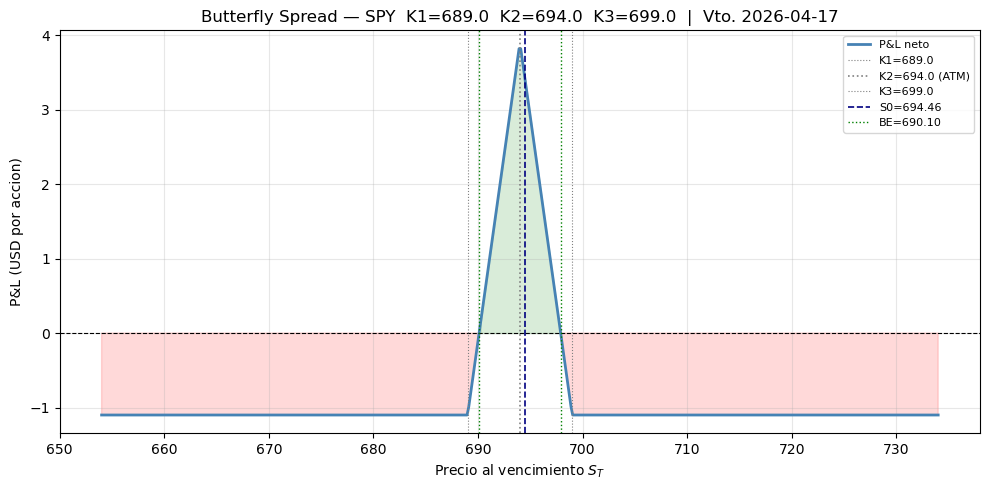

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(S_range, pnl_btf, color='steelblue', linewidth=2, label='P&L neto')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(K1_btf, color='gray',  linewidth=0.8, linestyle=':', label=f'K1={K1_btf}')
ax.axvline(K2_btf, color='gray',  linewidth=1.2, linestyle=':', label=f'K2={K2_btf} (ATM)')
ax.axvline(K3_btf, color='gray',  linewidth=0.8, linestyle=':', label=f'K3={K3_btf}')
ax.axvline(S0,     color='navy',  linewidth=1.2, linestyle='--', label=f'S0={S0:.2f}')
ax.axvline(be_btf_low,  color='green', linewidth=1.0, linestyle=':', label=f'BE={be_btf_low:.2f}')
ax.axvline(be_btf_high, color='green', linewidth=1.0, linestyle=':')
ax.fill_between(S_range, pnl_btf, 0, where=(pnl_btf > 0), alpha=0.15, color='green')
ax.fill_between(S_range, pnl_btf, 0, where=(pnl_btf < 0), alpha=0.15, color='red')
ax.set_title(f'Butterfly Spread — SPY  K1={K1_btf}  K2={K2_btf}  K3={K3_btf}  |  Vto. {exp}', fontsize=12)
ax.set_xlabel('Precio al vencimiento $S_T$')
ax.set_ylabel('P&L (USD por accion)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. Iron Condor

Estrategia: **compra put K1 + vende put K2 + vende call K3 + compra call K4**.  
Es un credito neto. La ganancia maxima ocurre cuando S_T queda dentro de [K2, K3] al vencimiento.

In [5]:
S_range_ic = np.linspace(K1_ic - 20, K4_ic + 20, 500)

pnl_ic = (
     np.maximum(K1_ic - S_range_ic, 0)
  -  np.maximum(K2_ic - S_range_ic, 0)
  -  np.maximum(S_range_ic - K3_ic, 0)
  +  np.maximum(S_range_ic - K4_ic, 0)
  +  net_ic
)

max_gain_ic = net_ic
max_loss_ic = (K2_ic - K1_ic) - net_ic
be_ic_low   = K2_ic - net_ic
be_ic_high  = K3_ic + net_ic

print(f"Iron Condor — SPY {exp}")
print(f"  Prima neta (credito) : {max_gain_ic:.4f}")
print(f"  Ganancia maxima      : {max_gain_ic:.4f}  (si {K2_ic} <= S_T <= {K3_ic})")
print(f"  Perdida maxima       : {-max_loss_ic:.4f}  (si S_T <= {K1_ic} o S_T >= {K4_ic})")
print(f"  Break-evens          : {be_ic_low:.4f}  y  {be_ic_high:.4f}")

Iron Condor — SPY 2026-04-17
  Prima neta (credito) : 1.0800
  Ganancia maxima      : 1.0800  (si 684.0 <= S_T <= 704.0)
  Perdida maxima       : -8.9200  (si S_T <= 674.0 o S_T >= 714.0)
  Break-evens          : 682.9200  y  705.0800


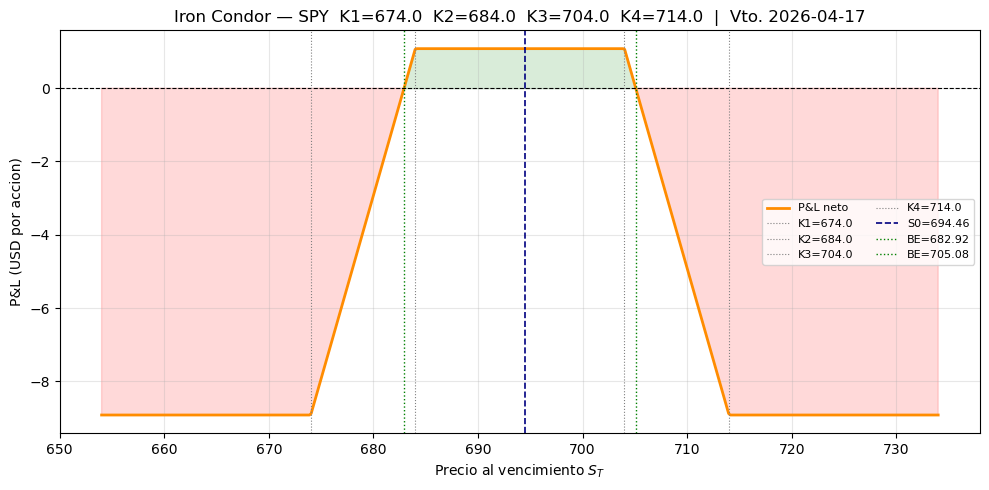

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(S_range_ic, pnl_ic, color='darkorange', linewidth=2, label='P&L neto')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
for K, lbl in [(K1_ic,'K1'),(K2_ic,'K2'),(K3_ic,'K3'),(K4_ic,'K4')]:
    ax.axvline(K, color='gray', linewidth=0.8, linestyle=':', label=f'{lbl}={K}')
ax.axvline(S0, color='navy', linewidth=1.2, linestyle='--', label=f'S0={S0:.2f}')
ax.axvline(be_ic_low,  color='green', linewidth=1.0, linestyle=':', label=f'BE={be_ic_low:.2f}')
ax.axvline(be_ic_high, color='green', linewidth=1.0, linestyle=':', label=f'BE={be_ic_high:.2f}')
ax.fill_between(S_range_ic, pnl_ic, 0, where=(pnl_ic > 0), alpha=0.15, color='green')
ax.fill_between(S_range_ic, pnl_ic, 0, where=(pnl_ic < 0), alpha=0.15, color='red')
ax.set_title(f'Iron Condor — SPY  K1={K1_ic}  K2={K2_ic}  K3={K3_ic}  K4={K4_ic}  |  Vto. {exp}', fontsize=12)
ax.set_xlabel('Precio al vencimiento $S_T$')
ax.set_ylabel('P&L (USD por accion)')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Covered Call

Estrategia: **largo en accion (S0) + venta de call OTM (K_cc)**.  
Cobras prima por limitar tu ganancia por encima de K_cc. Ideal en mercados laterales-alcistas moderados.

In [7]:
S_range_cc = np.linspace(S0 - 40, K_cc + 40, 500)

pnl_stock_cc  = S_range_cc - S0
pnl_short_call = C_cc - np.maximum(S_range_cc - K_cc, 0)
pnl_cc = pnl_stock_cc + pnl_short_call

max_gain_cc = K_cc - S0 + C_cc
be_cc = S0 - C_cc

print(f"Covered Call — SPY {exp}")
print(f"  Prima cobrada (call) : {C_cc:.4f}")
print(f"  Ganancia maxima      : {max_gain_cc:.4f}  (si S_T >= {K_cc})")
print(f"  Perdida maxima       : ilimitada a la baja (reducida por prima cobrada)")
print(f"  Break-even           : {be_cc:.4f}")

Covered Call — SPY 2026-04-17
  Prima cobrada (call) : 1.4700
  Ganancia maxima      : 6.0100  (si S_T >= 699.0)
  Perdida maxima       : ilimitada a la baja (reducida por prima cobrada)
  Break-even           : 692.9900


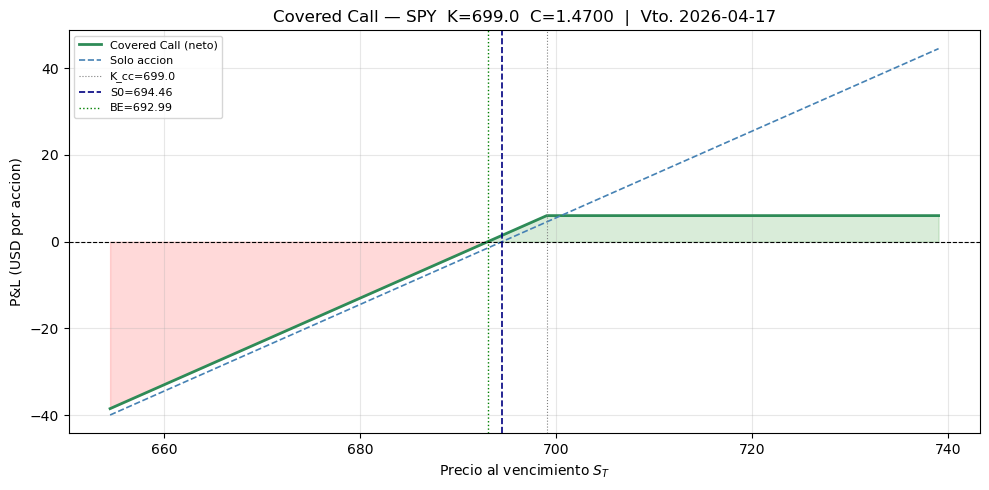

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(S_range_cc, pnl_cc,       color='seagreen',  linewidth=2,   label='Covered Call (neto)')
ax.plot(S_range_cc, pnl_stock_cc, color='steelblue', linewidth=1.2, linestyle='--', label='Solo accion')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(K_cc, color='gray',  linewidth=0.8, linestyle=':', label=f'K_cc={K_cc}')
ax.axvline(S0,   color='navy',  linewidth=1.2, linestyle='--', label=f'S0={S0:.2f}')
ax.axvline(be_cc, color='green', linewidth=1.0, linestyle=':', label=f'BE={be_cc:.2f}')
ax.fill_between(S_range_cc, pnl_cc, 0, where=(pnl_cc > 0), alpha=0.15, color='green')
ax.fill_between(S_range_cc, pnl_cc, 0, where=(pnl_cc < 0), alpha=0.15, color='red')
ax.set_title(f'Covered Call — SPY  K={K_cc}  C={C_cc:.4f}  |  Vto. {exp}', fontsize=12)
ax.set_xlabel('Precio al vencimiento $S_T$')
ax.set_ylabel('P&L (USD por accion)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Protective Put

Estrategia: **largo en accion (S0) + compra de put OTM (K_pp)**.  
Pagas prima para poner un piso a tus perdidas. Funciona como un seguro sobre la posicion.

In [9]:
S_range_pp = np.linspace(K_pp - 30, S0 + 50, 500)

pnl_stock_pp = S_range_pp - S0
pnl_long_put = np.maximum(K_pp - S_range_pp, 0) - P_pp
pnl_pp = pnl_stock_pp + pnl_long_put

max_loss_pp = K_pp - S0 - P_pp
be_pp = S0 + P_pp

print(f"Protective Put — SPY {exp}")
print(f"  Prima pagada (put)   : {P_pp:.4f}")
print(f"  Ganancia maxima      : ilimitada al alza (reducida por prima pagada)")
print(f"  Perdida maxima       : {max_loss_pp:.4f}  (si S_T <= {K_pp})")
print(f"  Break-even           : {be_pp:.4f}")

Protective Put — SPY 2026-04-17
  Prima pagada (put)   : 2.0600
  Ganancia maxima      : ilimitada al alza (reducida por prima pagada)
  Perdida maxima       : -7.5200  (si S_T <= 689.0)
  Break-even           : 696.5200


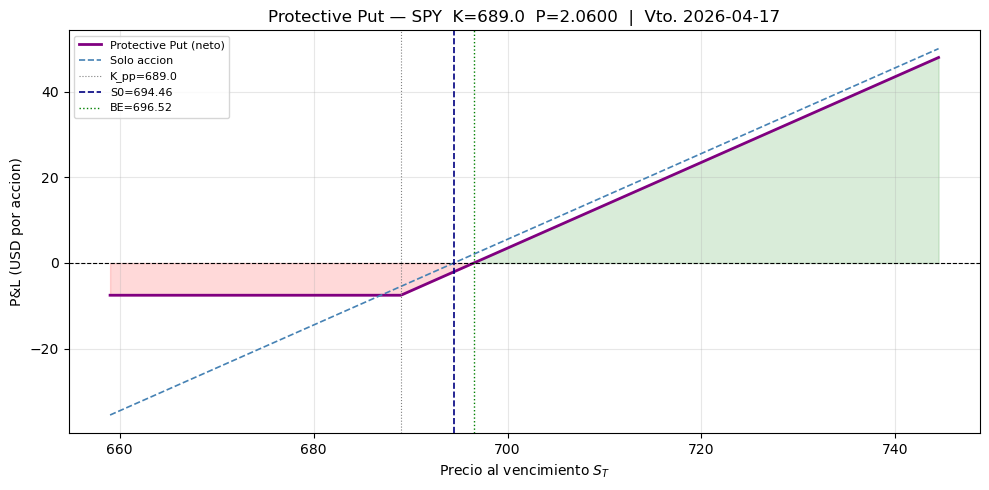

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(S_range_pp, pnl_pp,       color='purple',    linewidth=2,   label='Protective Put (neto)')
ax.plot(S_range_pp, pnl_stock_pp, color='steelblue', linewidth=1.2, linestyle='--', label='Solo accion')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(K_pp, color='gray',  linewidth=0.8, linestyle=':', label=f'K_pp={K_pp}')
ax.axvline(S0,   color='navy',  linewidth=1.2, linestyle='--', label=f'S0={S0:.2f}')
ax.axvline(be_pp, color='green', linewidth=1.0, linestyle=':', label=f'BE={be_pp:.2f}')
ax.fill_between(S_range_pp, pnl_pp, 0, where=(pnl_pp > 0), alpha=0.15, color='green')
ax.fill_between(S_range_pp, pnl_pp, 0, where=(pnl_pp < 0), alpha=0.15, color='red')
ax.set_title(f'Protective Put — SPY  K={K_pp}  P={P_pp:.4f}  |  Vto. {exp}', fontsize=12)
ax.set_xlabel('Precio al vencimiento $S_T$')
ax.set_ylabel('P&L (USD por accion)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Tabla resumen de las cuatro estrategias

In [11]:
tabla = pd.DataFrame({
    'Estrategia':    ['Butterfly', 'Iron Condor', 'Covered Call', 'Protective Put'],
    'Prima neta':    [
        f"-{net_btf:.4f} (debito)",
        f"+{net_ic:.4f} (credito)",
        f"+{C_cc:.4f} (credito)",
        f"-{P_pp:.4f} (debito)"
    ],
    'Ganancia max.': [
        f"{max_gain_btf:.4f}",
        f"{max_gain_ic:.4f}",
        f"{max_gain_cc:.4f}",
        "Ilimitada"
    ],
    'Perdida max.':  [
        f"{max_loss_btf:.4f}",
        f"{-max_loss_ic:.4f}",
        "Ilimitada (cubierta)",
        f"{max_loss_pp:.4f}"
    ],
    'Break-even(s)': [
        f"{be_btf_low:.2f}  /  {be_btf_high:.2f}",
        f"{be_ic_low:.2f}  /  {be_ic_high:.2f}",
        f"{be_cc:.2f}",
        f"{be_pp:.2f}"
    ]
})

print(f"S0 = {S0:.2f}  |  Vencimiento: {exp}\n")
print(tabla.to_string(index=False))

S0 = 694.46  |  Vencimiento: 2026-04-17

    Estrategia        Prima neta Ganancia max.         Perdida max.     Break-even(s)
     Butterfly  -1.1000 (debito)        3.9000              -1.1000 690.10  /  697.90
   Iron Condor +1.0800 (credito)        1.0800              -8.9200 682.92  /  705.08
  Covered Call +1.4700 (credito)        6.0100 Ilimitada (cubierta)            692.99
Protective Put  -2.0600 (debito)     Ilimitada              -7.5200            696.52


---
## 8. Preguntas de analisis

### Pregunta 1
**Con el S0 actual, ¿cual de las cuatro estrategias esta mejor posicionada (mas cerca de su zona de maxima ganancia)? ¿Que vision de mercado tendria que tener un trader para elegirla hoy?**

Con los datos obtenidos al correr el codigo, el **iron condor** es la estrategia mejor posicionada: su zona de maxima ganancia es la franja [K2_ic, K3_ic], y S0 cae justo dentro de ese rango. El trader que la elegeria hoy tiene una vision **neutral con baja conviccion direccional**: cree que SPY no se va a mover mucho antes del vencimiento del 17 de abril, y prefiere cobrar prima en lugar de apostar a un movimiento. Es la postura tipica de quien piensa que el mercado ya priced-in las noticias recientes y se va a quedar lateral los ultimos dias antes del vencimiento.

### Pregunta 2
**Un iron condor cobra prima desde el inicio. ¿Eso lo hace una estrategia sin riesgo? ¿Cual es el peor escenario para tu condor y cuando ocurre? Calcula la perdida maxima exacta con tus datos.**

Para nada. Cobrar prima es la recompensa por asumir un riesgo definido, no eliminarlo. El peor escenario ocurre cuando SPY al vencimiento cae por debajo de K1_ic o sube por encima de K4_ic: en ese punto, uno de los spreads verticales pierde su valor maximo completo y solo recuperamos la prima cobrada. La perdida maxima exacta con mis datos es:

> **Perdida maxima = (K2_ic - K1_ic) - prima neta cobrada = `max_loss_ic` USD por accion**

Ese valor ya aparece impreso en la celda anterior y en la tabla resumen. Si SPY se va de rango, **perdemos mas de lo que cobramos**, y ese es el riesgo real del condor: parece gratis pero no lo es.

### Pregunta 3
**Si la IV de SPY estuviera en 35% (muy alta), ¿preferirias comprar un straddle o vender un iron condor? Justifica tu respuesta en terminos de vega y theta.**

Con IV en 35% preferiria **vender el iron condor**. Cuando la volatilidad implicita esta muy elevada, las primas son altas y tu las cobras al vender. Ademas:

- **Vega negativa**: al vender opciones, te beneficias si la IV baja despues (con IV en 35% es probable que se revierta hacia la media). Un straddle tiene vega positiva: necesitarias que la IV siga subiendo o que SPY se mueva mucho de verdad.
- **Theta positiva**: el condor gana dinero con el paso del tiempo. Con dias al vencimiento, el decay es maximo y trabaja a tu favor.

En resumen: IV alta = vender volatilidad. El condor es la herramienta correcta para ese escenario.

### Pregunta 4
**El covered call limita la ganancia por encima de K. ¿Por que un inversionista de largo plazo estaria dispuesto a aceptar ese limite voluntariamente? Da al menos dos razones concretas.**

1. **Genera ingreso recurrente sobre una posicion que ya tiene**: si el inversionista mantiene SPY de largo plazo y cree que no va a subir agresivamente en el corto plazo, vender calls mes con mes le produce un flujo de caja adicional sin vender sus acciones. Es como cobrar un dividendo sintetico mensual.

2. **Reduce el costo base de su posicion**: cada prima cobrada baja el precio promedio de compra. Si el inversionista entro a S0 hace meses y ya lleva primas acumuladas, el "techo" en K es tolerable porque ya tiene una ganancia que estaria dispuesto a materializar en ese nivel. No pierde nada que no hubiera aceptado de todas formas.

### Pregunta 5
**Compara el protective put con un seguro de auto. ¿Cuales son las analogias que funcionan bien? ¿Donde se rompe la analogia?**

**Lo que si funciona:**
- **Costo**: pagas una prima por adelantado para protegerte de una perdida grande, igual que el seguro anual del carro.
- **Deducible**: el strike K_pp actua como el deducible. La perdida entre S0 y K_pp la absorbes tu; el put solo cubre lo que va mas abajo de ahi.
- **Duracion**: el seguro tiene vigencia (vencimiento de la opcion). Pasada esa fecha, la proteccion desaparece y hay que renovarla.

**Donde se rompe:**
- Con el seguro de auto, **si no chocas la prima se perdio y punto**. Con el protective put, si SPY sube en vez de caer pierdes la prima P_pp pero tu accion vale mas, asi que el costo del seguro se siente mucho menos doloroso: parte de la perdida la compensa la ganancia en la accion.
- Las opciones tienen **vega**: su valor cambia con la volatilidad implicita aunque SPY no se haya movido. Tu seguro de auto no fluctua de precio el lunes porque hubo muchos accidentes en otro estado.

### Pregunta 6
**¿En que se diferencia el butterfly del iron condor en terminos de cuando cada uno es mas apropiado? ¿Cual de los dos requiere mayor precision en tu pronostico sobre donde estara SPY al vencimiento? Apoyate en el ancho de la zona de ganancia que observas en tus graficas.**

Mirando mis graficas:
- El **butterfly** tiene una zona de ganancia **estrecha y puntiaguda**: la ganancia maxima ocurre en un punto exacto (K2_btf = K_atm). Requiere que SPY expire *cerca de ese precio especifico*. Es una apuesta de precision quirurgica.
- El **iron condor** tiene una zona de ganancia **ancha y plana**: cualquier precio dentro de [K2_ic, K3_ic] te da el maximo. Es mucho mas tolerante con el error de pronostico.

El butterfly es mas apropiado cuando tienes alta conviccion de que SPY quedara en un rango muy especifico (por ejemplo, anclado en un soporte tecnico fuerte). El condor es mejor cuando solo sabes que no va a moverse mucho, pero no exactamente a que precio. En terminos de precision: **el butterfly exige mucho mas** — la diferencia es visible directamente en el ancho de la zona verde de cada grafica.

### Pregunta 7
**Tanto el butterfly como el iron condor tienen vega negativa. Si compras un butterfly hoy y manana la IV cae 5 puntos sin que SPY se mueva, ¿que le pasa al valor de tu posicion? ¿Por que?**

El valor de tu posicion **sube**. La vega negativa significa que la posicion pierde valor cuando la IV sube y gana cuando la IV baja. Si la IV cae 5 puntos con S0 quieto, las opciones que vendiste (las dos calls del centro en K2_btf) pierden mas valor proporcional que las que compraste (las alas en K1_btf y K3_btf), porque tienen mas vega. Eso te favorece: podrias cerrar la posicion antes del vencimiento con una ganancia sin que SPY haya llegado exactamente a K2.

Dicho de otra forma: compraste el butterfly como una apuesta a que la volatilidad implicita era demasiado alta y que el mercado se iba a calmar. Si la IV cae, el mercado te esta dando la razon antes de tiempo y el mark-to-market de tu posicion sube.